In [ ]:
Content
1. Partitioning
2. Vertical vs Horizontal Partitioning
3. Sharding & Consistent Hasing
4. Scaling in SQL
    1. Replication
    2. Sharding/ Partitioning
    3. Distributed SQL
    4. Hybrid patterns

# 1. Partitioning

In [ ]:
Partitioning splits logical database objects (like tables or indexes) into multiple physical segments while keeping them logically as one.

Each partition can be stored:
    - In the same database or different databases
    - On the same or different disks

From a user's perspective, it’s still one table, but internally, it’s split.

Pros:
    ✅ Improved Query Performance	Queries can scan just the relevant partitions (partition pruning)
    ✅ Easier Maintenance	You can backup, rebuild, or truncate just one partition
    ✅ Parallelism	Partitions can be scanned in parallel
    ✅ Scalability	Supports managing very large datasets (VLDBs)
    ✅ Better Data Locality	Store "hot" and "cold" data separately

In [ ]:
In database partitioning, a query knows which partition to hit based on the partitioning strategy and the query WHERE clause, which allows the database engine to apply a process called partition pruning


How Query Chooses a Partition (Internally)
    a. When a table is partitioned, the database maintains metadata about:
        - Partition key (column used for partitioning)
        - Partition ranges or lists (depending on strategy)
        - Mapping between partition key values and physical partitions
    
    b. When a query runs, the optimizer:
        1. Analyzes the WHERE clause
        2. Matches the filter to the partition key
        3. Narrows down the list of partitions to scan
        4. Ignores others – this is called partition elimination / pruning

# Example
- SQL query
    CREATE PARTITION FUNCTION pfSalesRange (INT)
    AS RANGE LEFT FOR VALUES (2019, 2020, 2021);

- It Creates following 4 partitions:
    -- Partition 1: < 2019
    -- Partition 2: = 2019
    -- Partition 3: = 2020
    -- Partition 4: >= 2021

# When we run this query
    - SELECT * FROM Sales WHERE SaleYear = 2020;
    - The query engine automatically detects that only Partition 3 contains data for SaleYear = 2020 and scans only that partition.
    - This is done by the query optimizer using metadata and statistics.

# How Range Partitioning Works in SQL Server
When you partition a table in SQL Server:
	•	All partitions are logically one table to the query.
	•	The partition function decides where a row belongs based on your boundary values.
	•	SQL Server stores these partitions internally as separate B-trees (or heaps if no clustered index).
	•	The partition elimination feature allows SQL Server to scan only the partitions relevant to the WHERE clause.        

# FAQ
1. When we do a range query that require multiple partitions, then how it will work.
    - It will run query on both the table and return the concat result. It does parallel scan on relevant partitions.
    - Best performance is when the query hits a single partition only.                                                            

SELECT
    CONCAT results from:
       Partition 1 scan (filtered by WHERE)
       Partition 2 scan (filtered by WHERE)                                                            
        

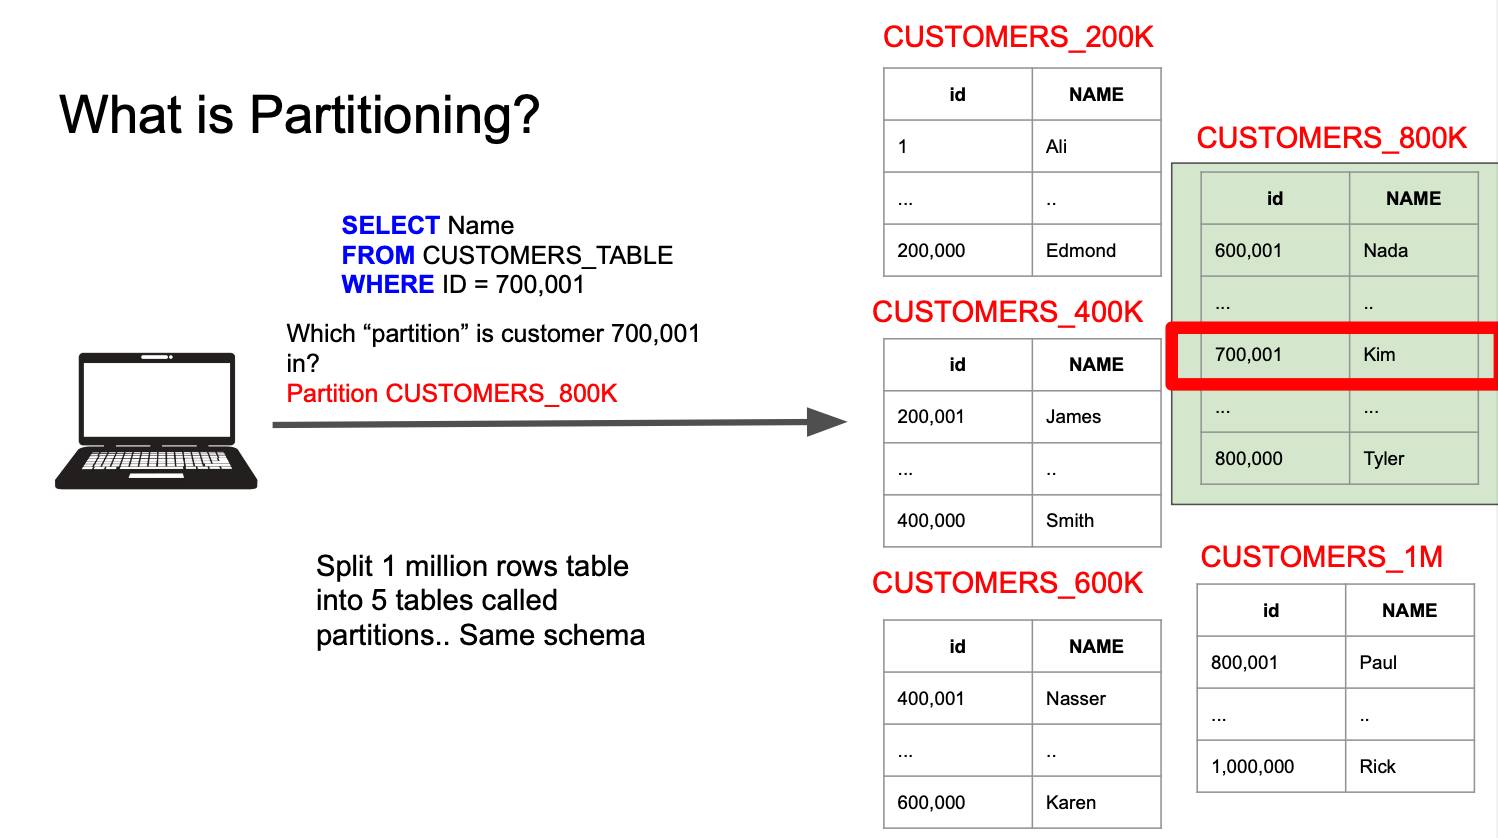

In [ ]:
# Partition Types

+----------------------+----------------------------+-------------------------------------------+-------------------------------------------+
| Partitioning Type    | Partitioning Basis        | When Pruning Works                        | Example WHERE Clause                      |
+----------------------+----------------------------+-------------------------------------------+-------------------------------------------+
| Range Partitioning   | Value ranges              | When filter uses partition key directly   | SaleDate >= '2022-01-01' AND < '2023-01-01' |
+----------------------+----------------------------+-------------------------------------------+-------------------------------------------+
| List Partitioning    | Explicit value list       | When filter matches list values           | Region IN ('East', 'West')                |
+----------------------+----------------------------+-------------------------------------------+-------------------------------------------+
| Hash Partitioning    | Hash of key value         | Harder; depends on exact match            | UserID = 123                               |
+----------------------+----------------------------+-------------------------------------------+-------------------------------------------+
| Composite Partition  | Combination (e.g., Range+)| Works when filter matches both keys       | SaleYear = 2023 AND Region = 'North'      |
+----------------------+----------------------------+-------------------------------------------+-------------------------------------------+

1. By Range (on dates)
    - Divide data based on a range of values in the partition key.
    - Example:
        Partition 1: OrderDate < '2023-01-01'
        Partition 2: OrderDate >= 2023-01-01 AND OrderDate < '2024-01-01'
        Partition 3: OrderDate >= 2024-01-01

2. By List 
    - Partitions data based on a discrete list of values.
    - (like states, or zip codes)
    - Example
        Partition 1: Region IN ('North', 'West')
        Partition 2: Region IN ('South')
        Partition 3: Region IN ('East')

3. By Hash (hash functions (consistant hashing)
    - Uses a hash function on the partition key to distribute rows.
    - It Evenly distributes data when ranges or lists aren’t suitable.
    - Example
        Partition 1: HASH(CustomerID) % 4 = 0
        Partition 2: HASH(CustomerID) % 4 = 1
        Partition 3: HASH(CustomerID) % 4 = 2
        Partition 4: HASH(CustomerID) % 4 = 3

4. Composite Paritioning (Hybrid partitioning)
    - Combines two or more partitioning strategies.
	- Example: Range + Hash

In [ ]:
# Partition Pruning
Partition pruning only occurs when the filter directly uses the partition key (and in some databases, also respects partition function constraints).

# turn on/ off pruning
    - Query: set enable_partition_pruning = off;
        - By turning it off, it will query on all the partition tables, all the partition table indexes will be used.
    - Query: set enable_partition_pruning = on;
        - By turning it on, it will query on required partitions only.
    

# Example List Partitioning
    - Each list item (or group of items) maps to a separate partition, which is internally like a separate table segment in most RDBMSs.
    - However, whether it is a completely separate physical table depends on the database engine.
    - Generic Query 
            PARTITION BY LIST (region) (
              PARTITION p_north VALUES IN ('North'),
              PARTITION p_south VALUES IN ('South'),
              PARTITION p_west  VALUES IN ('West', 'Midwest')
            );
    - This results in:
            p_north → data where region = 'North'
            p_south → data where region = 'South'
            p_west → data where region IN ('West', 'Midwest')

    - Each of these partitions holds only the matching rows, and partition pruning will scan only the relevant partition.

# Example in Postgress
CREATE TABLE employees (
  id INT,
  name TEXT,
  region TEXT
) PARTITION BY LIST (region);

CREATE TABLE employees_north PARTITION OF employees
  FOR VALUES IN ('North');

CREATE TABLE employees_south PARTITION OF employees
  FOR VALUES IN ('South');

SELECT * FROM employees WHERE region = 'South';

- employees_north and employees_south are actual tables that you can query directly.
- Query on employees table, will Prunes all partitions except employees_south and Only that table/segment is scanned


# Pros of Partitioning
    1. Improves query performance when accessing a single partition.
    2. Easy bulk loading, you can attach a table with million rows as a partition to a primary table.
    3. Archive old data into cheap storage.

# Cons of Partition
    1. Update a row that moves a row from a partition to another (slow or fail sometime)
    2. Inefficent queries could accidently scan all paritions resulting in slower performance.
    3. Schema changes can be challenging.

In [ ]:
# Postgress Create Partitions and Add to main table
# We have 1 billion customer, split into 100 table, so each table will have 10M

1. Create main table
  create table customers (id serial, name text) 
    paritition by range (id)

2. for i in range (100):
     id_from = i * 10000000
     id_to = (i+1) * 10000000
     partition_name = f'customers_{id_from}_{id_to}'
     create_query = f'create table {partition_name} (like customer including indexes)'
     attach_query = f'alter table customer
                         attach partition {partition_name}
                         for values from ({id_from}) to ({id_to});'

Now if Insert or fetch data to the main customers table, it will insert and fetch the data from respective partition table.

# 2. Vertical vs Horizontal Partitioning vs Sharding

In [ ]:
Horizontal Partitioning splits rows into partitions
    - Range or list

Vertical partitioning splits columns partitions
    - Large column (blob) that you can store in a slow access drive in its own tablespace
    - If you have a column with heavy text and if it is used rarely, then it is used.

In [ ]:
# Horizontal Partitioning vs Sharding
- Horizontal partitioning
    - HP splits a big table into multiple tables in the same database. Database takes care for partitioning
    - HP table name changes

- Sharding 
    - Sharding splits big table into multiple tables across multiple database servers.
        - Ex: We might have multiple database and based on your geo-location by IP address, your nearest database will serve the request.
+-----------------------------+------------------------------+-------------------------------+
|           Feature          |         Partitioning         |            Sharding           |
+-----------------------------+------------------------------+-------------------------------+
| Definition                 | Divides data within a table  | Divides data across databases |
| Scope                     | Single database/server        | Multiple databases/servers    |
| Managed By                | Database engine               | Application or middleware     |
| Transparency              | Transparent to applications   | Requires app logic awareness  |
| Use Case                  | Performance, maintenance      | Horizontal scalability        |
| Distribution Key          | Partition key (e.g., date)    | Shard key (e.g., user ID)     |
| Joins                     | Easy within partitioned table | Hard across shards            |
| Transactions              | Native support                | Complex (distributed Txns)    |
| Data Locality             | In same DB                    | Across different DBs/regions  |
| Example (SQL Server)      | Partitioned tables/indexes    | Manual sharding or Elastic DB |
| Example (MongoDB, etc.)   | Not typical                   | Native sharding support       |
| Fault Isolation           | No isolation (same DB)        | High isolation (per shard)    |
| Scaling Type              | Vertical / Partial horizontal | True horizontal scaling       |
| Maintenance               | Easier                        | More complex                  |
+-----------------------------+------------------------------+-------------------------------+


# 3. Sharding & Consistent Hasing

In [ ]:
Sharding is the process of splitting a single logical database into multiple smaller, independent databases (shards), each containing a subset of the data.
    - Each shard handles only a portion of the total dataset, based on a shard key.
    - Think of it as horizontal partitioning across multiple servers, not just within one.

Pros
	•	Scalability → Distribute large datasets across servers.
	•	Performance → Reduce query load per server.
	•	Fault Isolation → Failure in one shard doesn’t impact others.
	•	Geo Distribution → Place data near users.

Cons
    •	Schema changes are hard
    •	Rollbacks on multiple shards
    •	table joins
    •	Atomic transaction accross multiple database

# Key Sharding Concepts
	•	Shard Key → The column used to determine shard placement (must be chosen carefully).
	•	Shard Router / Coordinator → The middleware or database layer that decides which shard to query.
	•	Resharding → Moving data when shards become unbalanced.
	•	Cross-Shard Queries → Queries that need data from multiple shards; often costly.
	•	Shard Awareness in Application → Some systems require app to know which shard to connect to.

 

In [ ]:

Simple Hashing
    - To distribute data evenly accoss multiple server, a simple hashing can be used
    - ServerIndex = hash(key) % N, where N is the size of the server pool.
    - Simple hashing working, if the no. of servers are fixed.
        - but If either one server goes down, or if we want to add one more, then almost all of the keys needs to be re-mapped.
        - as %3 has been changed to %4.
    Idea: 
        - Assume we have three database
            - postgres: 5434
            - postgres: 5432
            - postgres: 5433
        - Given a user input of shard column value, 
            - Hash("userInput") = it will always give DB1
            - Hash("userInput1") = it will always give DB2

# Consistent Hashing
    - Consistent hashing is a data distribution strategy that maps keys to nodes in a way that minimizes remapping when nodes are added or removed.
    - Used in DB, horizontal scaling when data is distributed across many machines.
    - Objects (user values) and servers are hashed with the same hashing function to the same range of values.
    - If we compare it with simple hashing, only a fraction of keys needs to be re-mapped, If we add/remove a server.
    - Usecase:
        - Dynamo-style systems  for Data paritioning (Amazon dynoma DB, Dynamo DB)
        - CDN (Distribute web content evenly)
        - Load balancers (distribute persistent connections)
        - Native SQL DBs rarely use it directly inside the DB engine — they rely on range/hash partitioning instead.
    - Pros:
    	•	Scalability: Easy to add/remove servers without massive rebalancing.
    	•	Fault tolerance: Losing a node only affects a small portion of keys.
    	•	Load balancing: Keys distributed uniformly (if hash function is good).
    	•	Great for dynamic clusters.
    	•	Minimal data movement on topology change.
    	•	Works with replication easily.
    - Cons:
    	•	Slight complexity vs modulo hashing.
    	•	Requires good hashing to avoid hot spots.
    	•	Node lookup can be O(log N) without extra indexing (unless using jump hashing).
            
Key Terms:
- Range: the complete circle
- server placement: using a hashing function, we hash each DB server by its name or IP address,  and place the server on the ring.
- data placement: We hash the keys to the same range and place them in the same ring.

- Algo:
    - To find a server for a key, we just simply use the first clock-wise server we get.
    - Example (screenshot below): If we added a new server s4, then only k0 needs to be re-mapped.
        - Rest of the keys, does not require re-mapping.

Issue with basic Consistent Hashing
    -  (screenshot 2) It is very likely that the distributed of load is unequal on servers, some server will have too much load, and other will have very less.
    - If servers are frequently added or removed, then it is difficult to maintain even distribution.
        
# Virtual nodes are used to fix this problem
Idea: Each server will have multiple virtual nodes on the ring. (screenshot 3)
    - If no. of virtual nodes increases, the distribution becomes more balanced.


# Types
Type                  | Structure      | Lookup Complexity | Pros                               | Used in
--------------------- | -------------- | ----------------- | ---------------------------------- | --------------------
Simple Consistent Hash| Ring           | O(log N)          | Minimal remap on changes           | Early distributed caches
Virtual Nodes (VNodes)| Ring + multiple| O(log N)          | Better balance, less variance      | Cassandra, Dynamo
Rendezvous Hashing    | No ring        | O(N) or O(1) opt  | Simple, easy to implement          | Ceph, LB schedulers
Jump Consistent Hash  | Math formula   | O(1)              | Fast, memoryless                   | Big sharded DBs, LB        

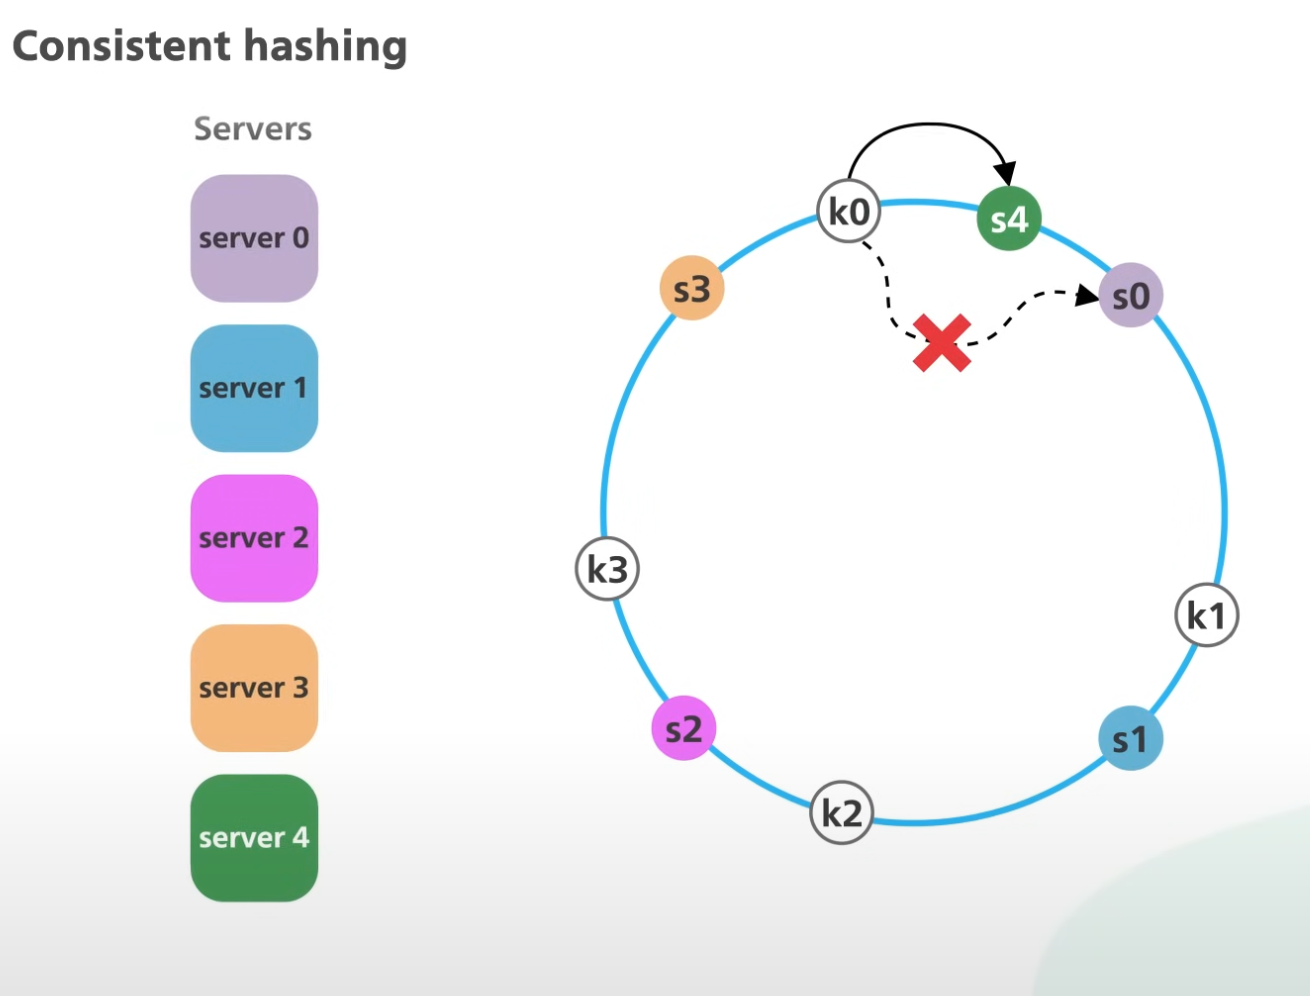
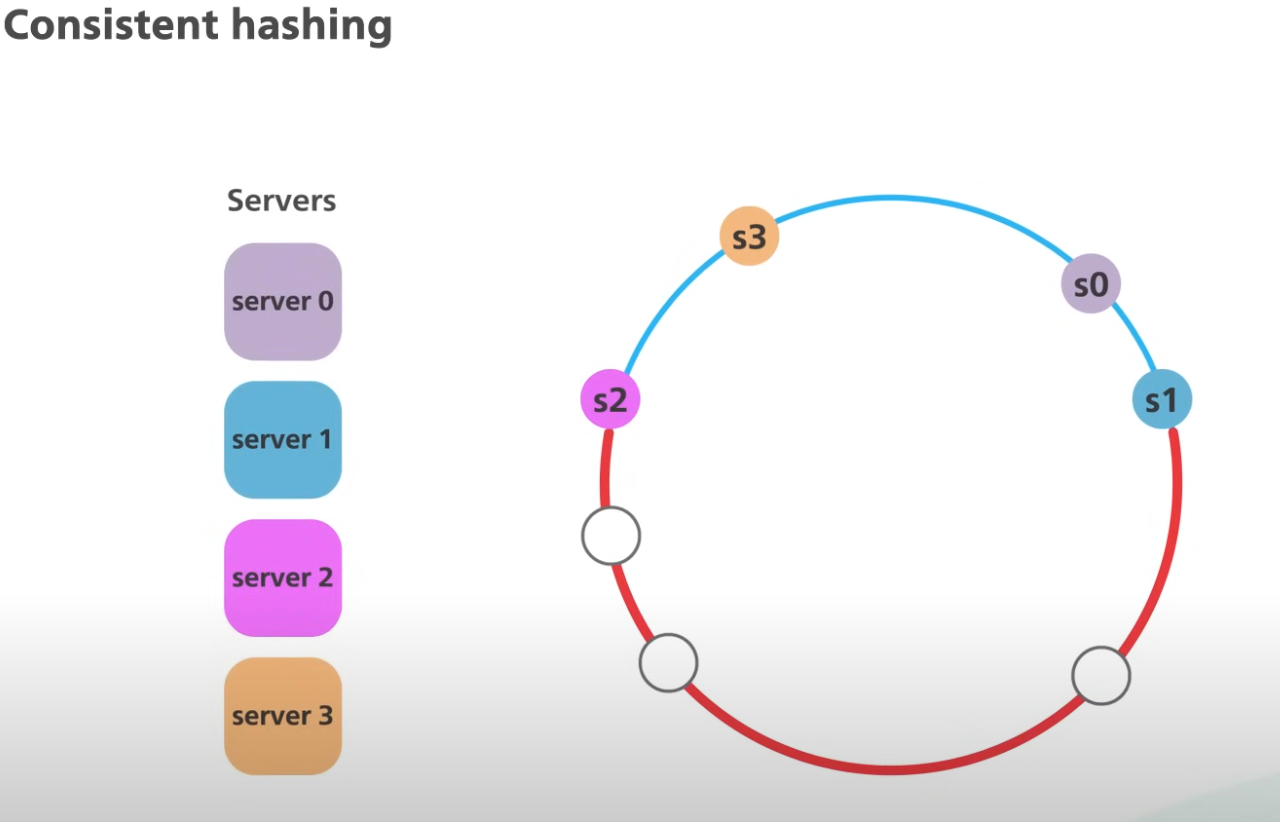
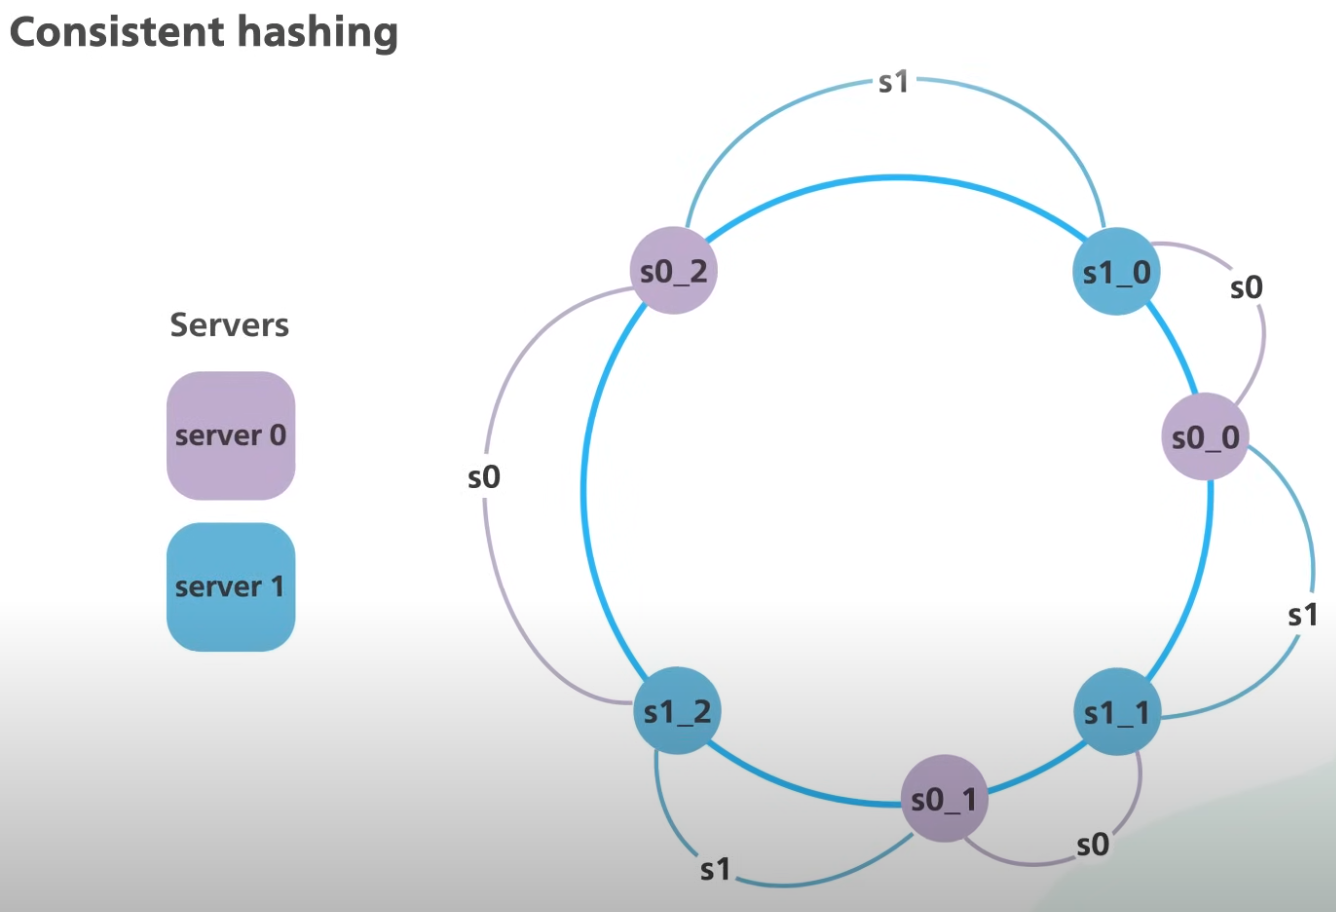

In [ ]:
import hashlib
import bisect

class ConsistentHashRing:
    def __init__(self, nodes=None, replicas=3):
        """
        nodes: list of node names (e.g., server1, server2)
        replicas: number of virtual nodes per physical node

        How it works
        	1.	Each server is represented by multiple virtual nodes on the hash ring to improve balance.
        	2.	A key (user ID, session ID, etc.) is hashed.
        	3.	We find the first node clockwise in the ring with a hash greater than or equal to the key’s hash.
        	4.	If we reach the end of the ring, we wrap to the start.
        	5.	When a new server is added, only the affected range of keys moves to the new server.
            
        """
        self.replicas = replicas
        self.ring = {}
        self.sorted_keys = []

        if nodes:
            for node in nodes:
                self.add_node(node)

    def _hash(self, key):
        """Return a hash value for the given key."""
        return int(hashlib.md5(key.encode('utf-8')).hexdigest(), 16)

    def add_node(self, node):
        """Add a physical node, along with virtual nodes."""
        for i in range(self.replicas):
            virtual_node_key = f"{node}#{i}"
            hash_val = self._hash(virtual_node_key)
            self.ring[hash_val] = node
            bisect.insort(self.sorted_keys, hash_val)

    def remove_node(self, node):
        """Remove a node and all its virtual nodes."""
        for i in range(self.replicas):
            virtual_node_key = f"{node}#{i}"
            hash_val = self._hash(virtual_node_key)
            del self.ring[hash_val]
            index = bisect.bisect_left(self.sorted_keys, hash_val)
            self.sorted_keys.pop(index)

    def get_node(self, key):
        """Get the node responsible for the given key."""
        if not self.ring:
            return None

        hash_val = self._hash(key)
        index = bisect.bisect(self.sorted_keys, hash_val)

        if index == len(self.sorted_keys):
            index = 0  # Wrap around the ring

        return self.ring[self.sorted_keys[index]]


# Example usage:
nodes = ["server1", "server2", "server3"]
ring = ConsistentHashRing(nodes, replicas=5)

users = ["alice", "bob", "charlie", "dave", "eve"]

for user in users:
    server = ring.get_node(user)
    print(f"User '{user}' is mapped to {server}")

# Add a new server and see remapping effect
print("\nAdding server4...")
ring.add_node("server4")

for user in users:
    server = ring.get_node(user)
    print(f"User '{user}' is now mapped to {server}")

In [ ]:
# What happens when a server is removed in consistent hashing
1. In-memory caches (e.g., Memcached, Redis cluster)
	•	Keys → represent cached objects.
	•	When a node is removed:
    	•	The mapping changes so that some keys now map to a different node.
    	•	No migration happens automatically — the cache doesn’t copy those keys from the old node (because the old node might be gone).
    	•	Those keys will simply be cache misses next time they’re requested, and the application will reload them from the backing store (e.g., SQL/NoSQL DB).
	•	So in caching, “keys move” means future requests for those keys will be routed to another server, not that data is copied immediately.

2. Persistent distributed databases (e.g., Cassandra, DynamoDB, Riak)
	•	Keys → represent actual persisted rows/records.
	•	When a node is removed or added:
        	1.	Cluster rebalances — the nodes that now own the key ranges will copy the relevant data from the old node(s) to themselves.
        	2.	If a node is removed because of failure, the system restores missing replicas from other healthy nodes.
        	3.	If you add a new node, existing nodes transfer a portion of their data to it (this is called streaming or rebalancing).
	•	So here, “keys move” means data is physically copied between database nodes so the ownership matches the new ring layout.
    -  So, when a new node is added, it
        1.	The new node gets the portion of keys it is now responsible for (based on its position in the hash ring).
    	2.	Other nodes give up ownership of that portion, meaning they remove those keys from their local storage after the data has been safely transferred.


    # Example
        Node A: owns 0 → 99
        Node B: owns 100 → 199
        Node C: owns 200 → 299
            If Node B fails:
            	•	Keys 100–199 are now mapped to Node C (next clockwise).
            	•	Node C copies those key-value pairs from Node B’s replicas (or from backups) so it has the correct data locally.

# 4. Scaling in SQL

In [ ]:
# Scaling in SQL
1. Replication
2. Sharding/ Partitioning
3. Distributed SQL
4. Hybrid patterns

How to decide:
 1. If your system has lot of read requests only, then Replication is the best.
 2. If your table is huge and you are scaning on large indexes which takes a lot of time, then partitioning is the best way. as everthing is still in the same server.
 3. If now, there are like so many DB connection on the same partitioning and DB is not able to handle queries.
     - then, try if we can introduce caching layer.
 4. Try, if we can have seperate DB, distributed geologically.
    - One country will have one server, another country will have another.
 5. then, Sharding is the last option, as it is the most complex.
    -  but then no ACID, Transactions, as table is splitted in different servers.
 6. Distributed SQL is really required.


1. Replication (Read Scaling / High Availability)
    - Replication is the process of keeping multiple copies of the same database in sync, usually with one primary (a.k.a. master) handling all writes and multiple replicas (a.k.a. slaves) serving read traffic.

    - How it works:
    	•	Writes: Go to the primary DB only.
    	•	Reads: Can go to either the primary (if fresh data needed) or replicas (to offload traffic).
    	•	Sync type:
        	1. Synchronous: 
                - Flow: Primary writes → sends changes to replica(s) → waits for them to confirm commit → then returns success to client.
            	- Guarantee: All committed writes exist in replicas before acknowledging to the app → replicas are always up-to-date.
            	- Trade-off: Higher write latency (because write has to travel over network + commit on replica), and if a replica is slow/unavailable, primary stalls or errors.
                - Primary waits until replica confirms write — stronger consistency, higher latency.
                - Example query
                    synchronous_commit = on
                        synchronous_standby_names = 'replica1,replica2'
                - For a new Read query
                	•	If no replicas are healthy → fail the read request (return error).
                	•	Else → route to a healthy replica.
                                      
        	2. Asynchronous: 
                - Primary returns success before replica writes — faster, but replicas can lag.
                - Default in many setups
                - Flow: Primary writes → returns success → later ships changes to replicas.
            	- Lag: Replicas can be milliseconds to seconds behind.
            	- Upside: Fast writes, low latency.
            	- Downside: Reads from replicas might see stale data.
            3. Semi-synchronous replication
            	•	Flow: Primary waits for at least one replica to acknowledge before committing.
            	•	Guarantee: At least one replica is up-to-date; others may lag.
            	•	Use case: Balances availability with latency.

    - Pros:
    	•	Easy to implement (most SQL engines support it).
    	•	Increases read throughput without changing schema.
    	•	Improves availability (replica can be promoted on primary failure).
        •	Horizontal Scaling
        •	Region based queries - DB per region.                                       
    
    - Cons:
        •	Eventual consistency
        •	Slow Writes (synchronous)                                       
    	•	Doesn’t improve write throughput (still one primary).
    	•	Replication lag can cause stale reads.
    	•	Failover needs orchestration.
           +------------+
           |   Primary  |  (Writes + some reads)
           +------------+
             /     |     \
            /      |      \
           v       v       v
   [Replica1] [Replica2] [Replica3]
    (Reads)    (Reads)    (Reads)

                                       
1.1 Multi-Master Replication
    - Multiple master/Leader node that accepts writes.


In [ ]:
2. Sharding/ Partitioning
    - Splitting data into shards (independent databases) where each shard contains a subset of the rows, determined by a shard key.
    - How it works:
    	•	Choose a shard key (e.g., customer_id, user_id).
    	•	Route queries to the shard that holds relevant data.
    	•	Each shard has its own CPU, memory, storage — can scale horizontally. 
    - Shard key strategies:
    	•	Hash sharding: shard_id = hash(user_id) % N — good distribution.
    	•	Range sharding: Based on ID/time ranges — easy range queries.
    	•	Lookup table: Central map from key → shard.
    - Pros:
    	•	Scales both reads & writes.
    	•	Allows virtually unlimited storage.
    	•	Each shard smaller → better query performance.
    - Cons:
    	•	Complex app logic/routing.
    	•	Cross-shard joins and transactions are hard.
    	•	Rebalancing/resharding can be painful.



[App] -> [Shard Router]
         /     |     \
        /      |      \
[Shard A]  [Shard B]  [Shard C]
(user_id 0-999) ... (user_id 2000+)

In [ ]:
3. Distributed SQL / NewSQL
    - A single logical SQL database spread across many nodes, providing:
    - Examples: Google Spanner, CockroachDB, YugabyteDB.
    - Pros:
        •	Automatic sharding
    	•	Distributed transactions
    	•	Strong consistency (often serializable isolation)
    	•	Transparency: app sees one DB.
    	•	Automatic scaling and rebalancing.
        •	Global transactions & strong consistency.
    - Cons:
    	•	Higher latency for writes (due to consensus).
    	•	Operational complexity unless managed (e.g., Spanner).
    	•	Still relatively new — fewer tooling/migration guides.

    - How it works:
    	•	Nodes store data partitions (shards) automatically.
    	•	System handles routing, replication, and rebalancing.
    	•	Transactions use consensus protocols (like Raft/Paxos).
    	•	Apps connect like to a normal SQL DB — no shard key logic needed.
    
    - When to use:
    	•	Need SQL + scale-out + strong consistency.
    	•	Multi-region/global availability needed.
    	•	Avoiding app-level sharding complexity.    

      [App] -> [Distributed SQL Endpoint]
                 /      |      \
            +---+---+  +---+---+  +---+---+
            | Node1 |  | Node2 |  | Node3 |
            +---+---+  +---+---+  +---+---+
               |          |          |
           [Shard A]  [Shard B]  [Shard C]


4. Hybrid Patterns
    - Mixing multiple techniques to balance performance, cost, and complexity.
    - Examples:
        	1.	Caching + Replication:
                    Cache hot reads in Redis; replicate DB for long-tail reads.
        	2.	CQRS (Command Query Responsibility Segregation):
                    Separate write-optimized DB from read-optimized DB (OLTP vs OLAP).
        	3.	Async Replication for Analytics:
                    Main DB → async replica/warehouse for reporting.
        	4.	Sharding + Replication:
                    Each shard has replicas for HA/read scaling.     


# CQRS (Command Query Responsibility Segregation) 
    - Command Query Responsibility Segregation is a design pattern where you separate the read and write operations of a system into different models.
    	1.	Command = Operations that change state (writes).
    	2.	Query = Operations that read state (reads).

    - Idea: Instead of having one single database schema/model for both reads and writes, you:
    	1.	Use a write model that is optimized for transactional integrity.
    	2.	Use a read model that is optimized for fast querying. 

    - How it works
    	1.	Commands go through the write model → persist to write DB.
    	2.	Write DB changes produce events (e.g., “OrderCreated”, “UserUpdated”).
    	3.	An event handler updates a read-optimized store (could be a cache, NoSQL DB, search index, etc.).
    	4.	Queries hit the read store for fast, precomputed results.  

    - Pros
    	1. Performance:
        	- Write side can focus on transactional correctness.
        	- Read side can be denormalized for speed.
    	2. Scalability:
        	- Scale reads and writes independently.
    	3. Flexibility:
        	- Read side can use a completely different database technology.          

    - Cons
    	•	Increased complexity (two models, syncing via events).
    	•	Eventual consistency on the read side.
    	•	More moving parts to monitor and maintain.
    
    - When to use CQRS
    	•	When read and write patterns are very different (e.g., 90% reads, 10% writes).
    	•	In large-scale systems where performance/scaling bottlenecks differ between reads and writes.
    	•	In event-driven architectures that already publish domain events.
        •	Example: in ecommerce, Write: a user places an order (affects multiple tables)
                                   Read: Get order history, can be served from a different DB.
                                           